###  0. Instalasi Library

In [1]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib joblib


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 📦 1. Import Library & Konfigurasi
Memuat library standar Python, Scikit-Learn, XGBoost, dan mengatur lokasi penyimpanan artefak model.

In [2]:
import os
import joblib
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
from sklearn.utils import class_weight
from xgboost import XGBClassifier

# ── Konfigurasi Nama File ──
DATASET_PATH     = "nhanes_complete_dataset.csv"
MODEL_PATH       = "model_xgboost.json"
SCALER_PATH      = "scaler.pkl"
ENCODER_PATH     = "label_encoder_gender.pkl"
EVALUASI_PATH    = "hasil_evaluasi.txt"
CM_PATH          = "confusion_matrix.png"
FI_PATH          = "feature_importance.png"

TEST_SIZE        = 0.2  # 80% Train, 20% Test
RANDOM_STATE     = 42

FITUR_KOLOM      = ['Age', 'Gender', 'Height', 'Weight', 'BMI', 'HeartRate', 'Temperature']
TARGET_KOLOM     = 'Diabetes'

### 📁 2. Membaca & Validasi Dataset (`nhanes_complete_dataset.csv`)
Pastikan file `nhanes_complete_dataset.csv` sudah diunggah di folder Colab.

In [3]:
if not os.path.isfile(DATASET_PATH):
    print(f"[ERROR] File '{DATASET_PATH}' tidak ditemukan!")
    print("Silakan upload file 'nhanes_complete_dataset.csv' ke folder Colab terlebih dahulu.")
else:
    # Membaca dataset CSV (support pemisah ';' dan ',')
    df = pd.read_csv(DATASET_PATH, sep=';', encoding='utf-8')
    if len(df.columns) == 1 and ';' not in df.columns[0]:
        df = pd.read_csv(DATASET_PATH, sep=',', encoding='utf-8')
    
    print(f"✓ Dataset dimuat : {df.shape[0]} baris, {df.shape[1]} kolom")
    display(df.head())

✓ Dataset dimuat : 9254 baris, 8 kolom


,Age,Gender,Height,Weight,BMI,HeartRate,Temperature,Diabetes
0,2,Female,88.6,13.7,17.5,120.0,NaN,No Diabetes
1,2,Male,94.2,13.9,15.7,114.0,98.71,No Diabetes
2,66,Female,158.3,79.5,31.7,52.0,98.26,No Diabetes
3,18,Male,175.7,66.3,21.5,82.0,98.84,No Diabetes
4,13,Male,158.4,45.4,18.1,100.0,98.48,No Diabetes


### 🧹 3. Pra-Pemrosesan Data (Data Preprocessing)
Membersihkan missing values, melakukan label encoding pada variabel kategorik (`Gender`), dan mengisi data kosong dengan **Imputasi Median**.

In [4]:
# Hapus baris dengan label target kosong
df = df[df[TARGET_KOLOM].notna()].copy()

# Enkode Gender: Male -> 1, Female -> 0
le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'].astype(str))

# Enkode Target: Diabetes -> 1, No Diabetes -> 0
df[TARGET_KOLOM] = df[TARGET_KOLOM].map({'Diabetes': 1, 'No Diabetes': 0})

# Imputasi missing values dengan median
for col in FITUR_KOLOM:
    if df[col].isna().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

# Pisahkan matriks fitur (X) dan target (y)
X = df[FITUR_KOLOM].values
y = df[TARGET_KOLOM].values

print(f"✓ Pra-pemrosesan selesai! Ukuran X: {X.shape}, Ukuran y: {y.shape}")

✓ Pra-pemrosesan selesai! Ukuran X: (8709, 7), Ukuran y: (8709,)


### ✂️ 4. Pembagian Data (Train & Test Split)
Membagi data menjadi **80% Data Latih (Train)** dan **20% Data Uji (Test)** menggunakan `stratify` agar rasio kelas seimbang.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"✓ Data Training : {X_train.shape[0]} baris")
print(f"✓ Data Testing  : {X_test.shape[0]} baris")

✓ Data Training : 6967 baris
✓ Data Testing  : 1742 baris


### ⚖️ 5. Standarisasi Fitur & Penanganan Class Imbalance
Menggunakan `StandardScaler` untuk normalisasi numerik dan menghitung `scale_pos_weight` untuk kelas imbalanced.

In [6]:
# Standarisasi Fitur
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Hitung Class Weight
classes     = np.unique(y_train)
weights     = class_weight.compute_class_weight('balanced', classes=classes, y=y_train)
scale_pos_w = weights[1] / weights[0]

print(f"✓ Normalisasi fitur selesai! scale_pos_weight = {scale_pos_w:.4f}")

✓ Normalisasi fitur selesai! scale_pos_weight = 8.7577


### 🚀 6. Pelatihan Model XGBoost & Tuning Hyperparameter
Mencari kombinasi hyperparameter terbaik menggunakan **GridSearchCV** dan **5-Fold Cross Validation**.

In [7]:
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [3, 5, 7],
    'learning_rate'    : [0.01, 0.05, 0.1],
    'subsample'        : [0.8, 1.0],
    'colsample_bytree' : [0.8, 1.0],
}

xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_w,
    random_state=RANDOM_STATE,
    use_label_encoder=False,
    verbosity=0,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

best_model  = grid_search.best_estimator_
best_params = grid_search.best_params_

print(f"\n✓ Hyperparameter Terbaik:")
for k, v in best_params.items():
    print(f"   {k:<20}: {v}")
print(f"✓ F1-Score CV Terbaik   : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits

✓ Hyperparameter Terbaik:
   colsample_bytree    : 0.8
   learning_rate       : 0.01
   max_depth           : 7
   n_estimators        : 200
   subsample           : 0.8
✓ F1-Score CV Terbaik   : 0.4347


### 📊 7. Evaluasi Performa Model pada Data Testing
Menghitung metrik **Accuracy, Precision, Recall, F1-Score, AUC-ROC**, dan menampilkan Classification Report.

In [8]:
y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
auc       = roc_auc_score(y_test, y_pred_prob)
cm        = confusion_matrix(y_test, y_pred)

print("┌─────────────────────────────────┐")
print("│        HASIL EVALUASI MODEL     │")
print("├─────────────────────────────────┤")
print(f"│  Accuracy       : {acc:.4f}        │")
print(f"│  Precision      : {precision:.4f}        │")
print(f"│  Recall         : {recall:.4f}        │")
print(f"│  F1-Score       : {f1:.4f}        │")
print(f"│  AUC-ROC        : {auc:.4f}        │")
print("└─────────────────────────────────┘")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

┌─────────────────────────────────┐
│        HASIL EVALUASI MODEL     │
├─────────────────────────────────┤
│  Accuracy       : 0.7790        │
│  Precision      : 0.2915        │
│  Recall         : 0.8045        │
│  F1-Score       : 0.4279        │
│  AUC-ROC        : 0.8490        │
└─────────────────────────────────┘

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.97      0.78      0.86      1563
    Diabetes       0.29      0.80      0.43       179

    accuracy                           0.78      1742
   macro avg       0.63      0.79      0.65      1742
weighted avg       0.90      0.78      0.82      1742



### 💾 8. Simpan Model & Artefak
Menyimpan model ke `model_xgboost.json`, scaler ke `scaler.pkl`, dan encoder ke `label_encoder_gender.pkl` yang digunakan untuk deployment API.

In [9]:
best_model.save_model(MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)
joblib.dump(le_gender, ENCODER_PATH)

print(f"✓ Model disimpan    : {MODEL_PATH}")
print(f"✓ Scaler disimpan   : {SCALER_PATH}")
print(f"✓ Encoder disimpan  : {ENCODER_PATH}")

✓ Model disimpan    : model_xgboost.json
✓ Scaler disimpan   : scaler.pkl
✓ Encoder disimpan  : label_encoder_gender.pkl


### 📈 9. Visualisasi Graphics (Confusion Matrix & Feature Importance)

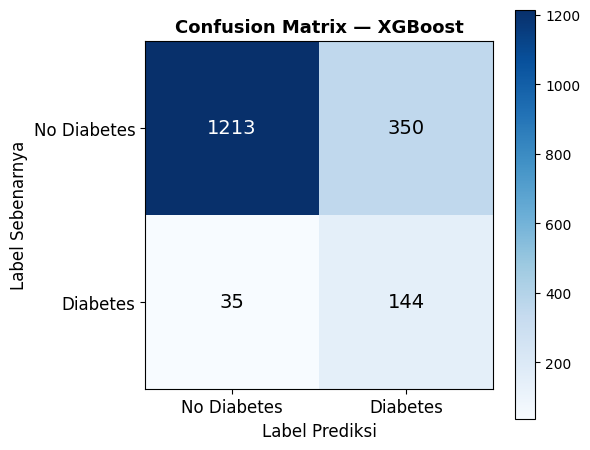

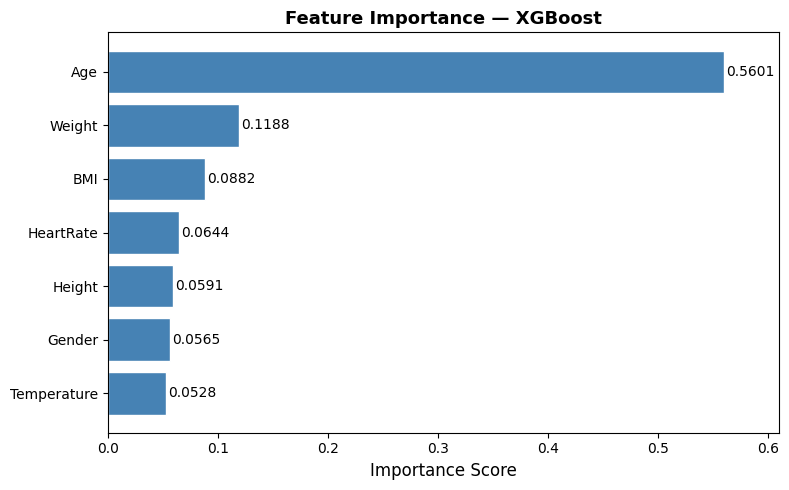

In [10]:
# ── Visualisasi Confusion Matrix ──
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)

classes_label = ['No Diabetes', 'Diabetes']
tick_marks = np.arange(len(classes_label))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(classes_label, fontsize=12)
ax.set_yticklabels(classes_label, fontsize=12)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center", fontsize=14,
                color="white" if cm[i, j] > thresh else "black")

ax.set_ylabel('Label Sebenarnya', fontsize=12)
ax.set_xlabel('Label Prediksi', fontsize=12)
ax.set_title('Confusion Matrix — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CM_PATH, dpi=150)
plt.show()

# ── Visualisasi Feature Importance ──
importances = best_model.feature_importances_
indices     = np.argsort(importances)[::-1]
feat_names  = [FITUR_KOLOM[i] for i in indices]
feat_scores = importances[indices]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(feat_names[::-1], feat_scores[::-1], color='steelblue', edgecolor='white')

for bar, score in zip(bars, feat_scores[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{score:.4f}', va='center', fontsize=10)

ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Feature Importance — XGBoost', fontsize=13, fontweight='bold')
ax.set_xlim(0, max(feat_scores) + 0.05)
plt.tight_layout()
plt.savefig(FI_PATH, dpi=150)
plt.show()

### 🤖 10. Pengujian Prediksi (Simulasi Data Sensor ESP32)
Menguji fungsi prediksi menggunakan contoh masukan variabel sensor (MAX30102 & MLX90614).

In [11]:
def prediksi_risiko_diabetes(age, gender, height, weight, bmi, heart_rate, temperature_celsius):
    model_test = XGBClassifier()
    model_test.load_model(MODEL_PATH)
    sc_test = joblib.load(SCALER_PATH)
    le_test = joblib.load(ENCODER_PATH)

    gender_enc = le_test.transform([gender])[0]
    input_data = np.array([[age, gender_enc, height, weight, bmi, heart_rate, temperature_celsius]])
    input_scaled = sc_test.transform(input_data)

    label_enc = model_test.predict(input_scaled)[0]
    prob      = model_test.predict_proba(input_scaled)[0]

    label   = 'Diabetes' if label_enc == 1 else 'No Diabetes'
    prob_dm = round(float(prob[1]) * 100, 2)
    prob_no = round(float(prob[0]) * 100, 2)

    if label == 'Diabetes':
        rekomendasi = "RISIKO TINGGI: Disarankan konsultasi ke dokter dan batasi konsumsi gula."
        aksi_snack  = "DITOLAK — Smart Snack Box TERKUNCI"
    else:
        rekomendasi = "RISIKO RENDAH: Tetap jaga pola makan dan aktivitas fisik yang sehat."
        aksi_snack  = "DIIZINKAN — Smart Snack Box TERBUKA"

    return {
        'label'         : label,
        'probabilitas'  : {'Diabetes': f'{prob_dm}%', 'No Diabetes': f'{prob_no}%'},
        'rekomendasi'   : rekomendasi,
        'aksi_snack_box': aksi_snack,
    }

# ── Simulasi ──
contoh_input = {
    'age'                  : 13,
    'gender'               : 'Male',
    'height'               : 155.0,
    'weight'               : 60.0,
    'bmi'                  : 24.97,
    'heart_rate'           : 88,    # MAX30102
    'temperature_celsius'  : 37.2,  # MLX90614
}

hasil = prediksi_risiko_diabetes(**contoh_input)
print("Hasil Prediksi Simulasi ESP32:")
for key, val in hasil.items():
    print(f"  {key:<15}: {val}")

Hasil Prediksi Simulasi ESP32:
  label          : No Diabetes
  probabilitas   : {'Diabetes': '16.68%', 'No Diabetes': '83.32%'}
  rekomendasi    : RISIKO RENDAH: Tetap jaga pola makan dan aktivitas fisik yang sehat.
  aksi_snack_box : DIIZINKAN — Smart Snack Box TERBUKA
